# **PREPROCESSING**

### **LIBRARIES**

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display
import scipy.signal
import soundfile as sf
from tqdm import tqdm
from scipy.signal import butter, filtfilt, correlate
import scipy.stats
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from mpl_toolkits.mplot3d import Axes3D
from typing import Union, Tuple
import plotly.express as px
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_selection import f_classif, mutual_info_classif
import yaml
import re
from collections import Counter
from collections import defaultdict

Load parameters and other configuration values.

In [3]:
# Load audio preprocessing constants from config.yaml
with open("config.yaml", "r") as f:
    config = yaml.safe_load(f)

SAMPLING_RATE = config["audio_processing"]["sampling_rate"] # Resample the audio files with frequency 4 kHz, since wheezes and crackles are typically within frequency range 0–2 kHz
FRAME_LENGTH = config["audio_processing"]["frame_length"] # Use window size of 0.3 s for each cycle
HOP_LENGTH = config["audio_processing"]["hop_length"] # Use 50% overlap
N_MFCC = config["audio_processing"]["n_mfcc"] # Extract the first 13 MFCCs
N_MELS = config["audio_processing"]["n_mels"] # Use 20 Mel Banks to extract the Log-Mel Spectrograms
F_HI = config["audio_processing"]["f_hi"] # Boundary frequency for VLTP is set to 2 kHz
TARGET_DURATION = config["audio_processing"]["target_duration"] # Fix the duration of each cycle to 8 s

FRAME_SIZE = int(FRAME_LENGTH * SAMPLING_RATE) # Calculate the amount of samples per frame
HOP_SIZE = int(HOP_LENGTH * SAMPLING_RATE) #  Calculate the amount of samples per hop

# Load basic paths from config.yaml
DATA_FOLDER = os.path.join(os.getcwd(), config["paths"]["data_folder"])
AUDIO_FOLDER = os.path.join(os.getcwd(), config["paths"]["audio_folder"])
OUTPUT_FOLDER = os.path.join(os.getcwd(), config["paths"]["output_folder"])
RAW_CYCLE_FOLDER = os.path.join(os.getcwd(), config["paths"]["raw_cycle_folder"])
AUG_CYCLE_FOLDER = os.path.join(os.getcwd(), config["paths"]["aug_cycle_folder"])
CLEANED_CYCLE_FOLDER = os.path.join(os.getcwd(), config["paths"]["cleaned_cycle_folder"])
TRAINING_SET_FOLDER = os.path.join(os.getcwd(), config["paths"]["training_set_folder"])
TEST_SET_FOLDER = os.path.join(os.getcwd(), config["paths"]["test_set_folder"])

os.makedirs(OUTPUT_FOLDER, exist_ok=True)
os.makedirs(RAW_CYCLE_FOLDER, exist_ok=True)
os.makedirs(AUG_CYCLE_FOLDER, exist_ok=True)
os.makedirs(CLEANED_CYCLE_FOLDER, exist_ok=True)
os.makedirs(TRAINING_SET_FOLDER, exist_ok=True)
os.makedirs(TEST_SET_FOLDER, exist_ok=True)

We plot for example the first 5 .wav files of the RSDB dataset and visualize the class of every respiratory cycle they contain for better understanding. 

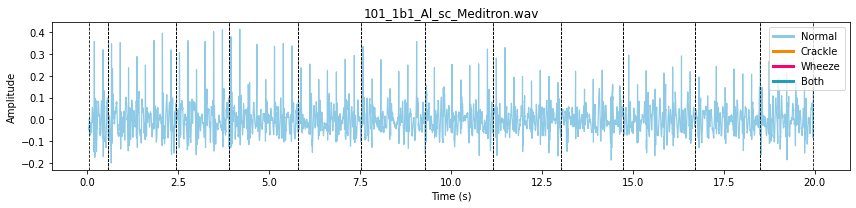

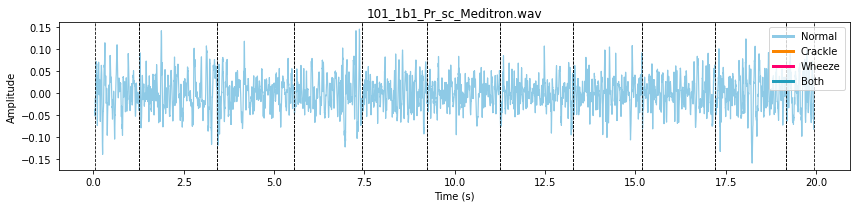

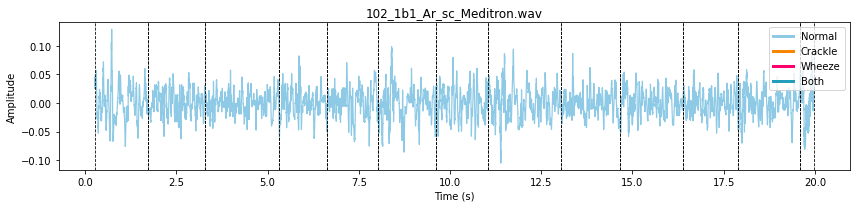

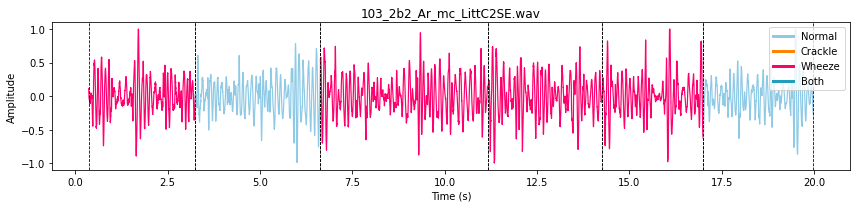

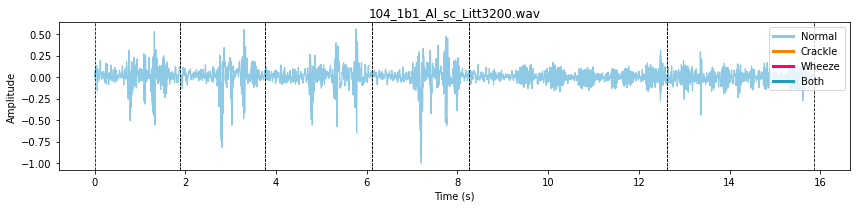

In [3]:
from utils.visuals import plot_dataset_waveforms

plot_dataset_waveforms(AUDIO_FOLDER, k=5, sr=SAMPLING_RATE)

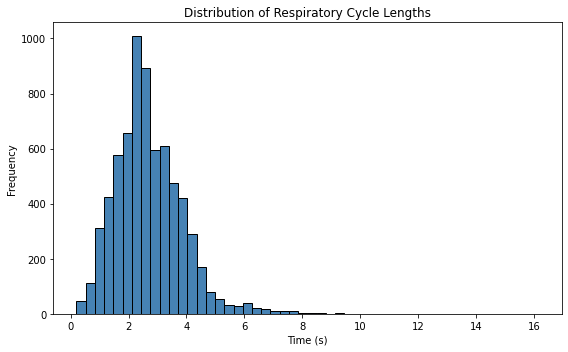

In [50]:
from utils.visuals import plot_cycle_duration_distribution

plot_cycle_duration_distribution(AUDIO_FOLDER)

Then, for the preprocessing we apply the following pipeline: 
1. **Resample** all .wav files with **SAMPLING RATE = 4 kHz**. Also, we will use a **frame window of duration  60 ms** and **50% overlap** between windows
2. **Split all .wav files into respiratory cycles** using the annotation files and **fix their length into 3s using circular padding**
3. Split the respiratory cycles into **training and testing set**
4. Locate which classes are underrepresented in training set and **apply VLTP to handle class imbalance** and enhance the robustness of time-domain acoustic features
5. Apply on every cycle of both training and testing set a **highpass filter with cut-off frequency = 50 Hz** to remove heart sounds and silent environmental noise. Also **normalize the signal amplitude in the interval [-1,1]**

In [5]:
from utils.audio_preprocessing import (
    fix_cycle_length, classify, apply_vtlp,
    preprocess_audio
)

# Steps 1 & 2: Resample and segment raw audio files into respiratory cycles with fixed length using annotation files
raw_rows = []
for file in os.listdir(AUDIO_FOLDER):
    if file.endswith(".wav"):
        name = file.replace(".wav", "")
        txt_path = os.path.join(AUDIO_FOLDER, name + ".txt")
        if not os.path.exists(txt_path):
            continue

        y, sr = librosa.load(os.path.join(AUDIO_FOLDER, file), sr=SAMPLING_RATE)
        annotations = np.loadtxt(txt_path)

        for i, (start, end, crackle, wheeze) in enumerate(annotations):
            y_seg = fix_cycle_length(y[int(start * sr):int(end * sr)], sr, target_duration=TARGET_DURATION)
            if len(y_seg) < 2 or np.isnan(y_seg).any():
                print(f"Skipping invalid segment: {name}_cycle{i}")
                continue
            fname = f"{name}_cycle{i}.wav"
            sf.write(os.path.join(RAW_CYCLE_FOLDER, fname), y_seg, sr)
            raw_rows.append([fname, int(crackle), int(wheeze)])

df = pd.DataFrame(raw_rows, columns=["file", "crackle", "wheeze"])
df["class"] = df.apply(lambda r: classify(r["crackle"], r["wheeze"]), axis=1)

# Remove class 'Both' since we will not use it from now on
df = df[df["class"] != "Both"].reset_index(drop=True)

# Step 3: Split cycles into train/test sets for the classification using stratified split to preserve the class ratio
train_df, test_df = train_test_split(df, test_size=0.2, stratify=df["class"], random_state=42)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

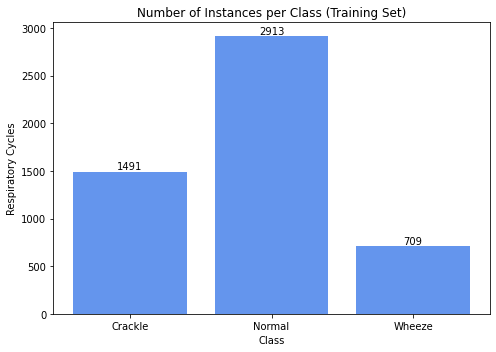

In [6]:
# Visualize class imbalance in training set
label_counts = Counter(train_df["class"])

plt.figure(figsize=(7, 5))
plt.bar(label_counts.keys(), label_counts.values(), color="cornflowerblue")
plt.title("Number of Instances per Class (Training Set)")
plt.xlabel("Class")
plt.ylabel("Respiratory Cycles")

for i, (label, count) in enumerate(label_counts.items()):
    plt.text(i, count + 1, str(count), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

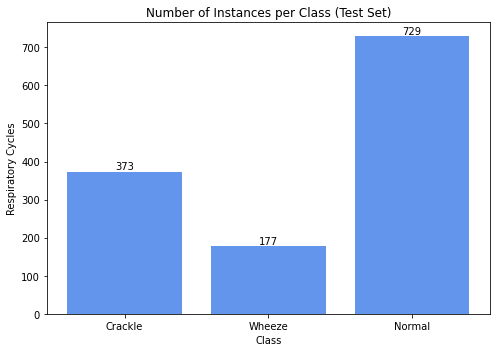

In [7]:
# Visualize class imbalance in test set
label_counts = Counter(test_df["class"])

plt.figure(figsize=(7, 5))
plt.bar(label_counts.keys(), label_counts.values(), color="cornflowerblue")
plt.title("Number of Instances per Class (Test Set)")
plt.xlabel("Class")
plt.ylabel("Respiratory Cycles")

for i, (label, count) in enumerate(label_counts.items()):
    plt.text(i, count + 1, str(count), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

The bar chart shows a **clear class imbalance in BOTH training and test set**. Specifically, the **"Normal" class dominates** the dataset with significantly more samples compared to the "Crackle", "Wheeze". This imbalance may lead to biased model performance, so we handle it by appling **VTLP Data Augmentation** on the training set. The test set on the other hand must remain as it is.

In [9]:
# Set uniform target count for all classes
target_count = len(train_df[train_df["class"] == "Normal"])
augmented_labels = []

for cls in train_df["class"].unique():
    df_cls = train_df[train_df["class"] == cls]
    current_count = len(df_cls)
    n_needed = target_count - current_count

    n_per_sample = int(np.ceil(n_needed / current_count))

    if cls != 'Normal':
        print(f"Augmenting class {cls} with {n_needed} new samples ({n_per_sample} per original)")

        for idx, (_, row) in tqdm(enumerate(df_cls.iterrows()), total=len(df_cls), desc=f"Augmenting class {cls}"):
            for j in range(n_per_sample):
                if n_needed <= 0:
                    break

                path = os.path.join(RAW_CYCLE_FOLDER, row["file"])
                y, sr = librosa.load(path, sr=SAMPLING_RATE)

                alpha = np.random.uniform(0.8, 1.2) if cls in ["Crackle", "Wheeze"] else np.random.uniform(0.9, 1.1)

                y_aug = apply_vtlp(
                    y, sr,
                    frame_size=FRAME_SIZE,
                    hop_size=HOP_SIZE,
                    n_mels=N_MELS,
                    f_hi=F_HI,
                    alpha=alpha
                )
                y_aug = fix_cycle_length(y_aug, sr, target_duration=TARGET_DURATION)
                fname = f"AUG_{row['file'].replace('.wav', '')}_vtlp{idx}_{j}.wav"
                sf.write(os.path.join(AUG_CYCLE_FOLDER, fname), y_aug, sr)

                augmented_labels.append({
                    "file": fname,
                    "crackle": int(row["crackle"]),
                    "wheeze": int(row["wheeze"]),
                    "class": classify(int(row["crackle"]), int(row["wheeze"]))
                })

                n_needed -= 1

# Save final augmented labels
augmented_labels_df = pd.DataFrame(augmented_labels)

Augmenting class Crackle with 1422 new samples (1 per original)


Augmenting class Crackle: 100%|██████████| 1491/1491 [02:24<00:00, 10.34it/s]


Augmenting class Wheeze with 2204 new samples (4 per original)


Augmenting class Wheeze: 100%|██████████| 709/709 [03:18<00:00,  3.58it/s]


We then plot some of the augmented files to check if their spectral behavior is similar.

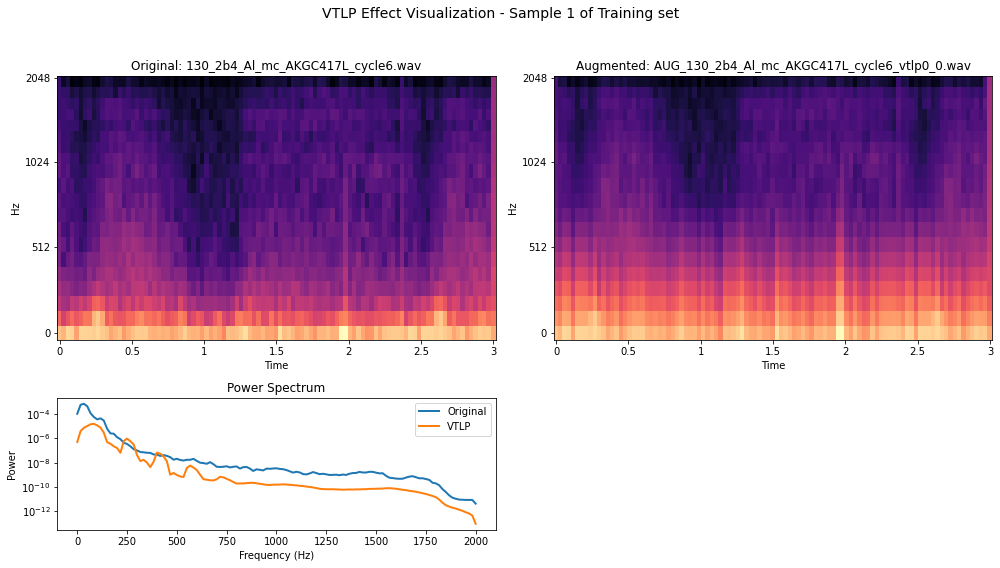

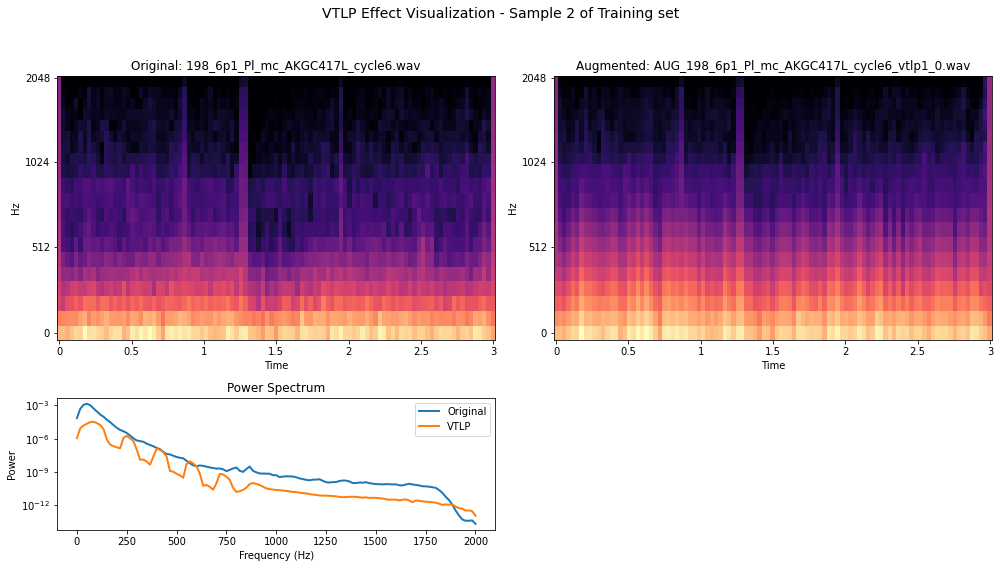

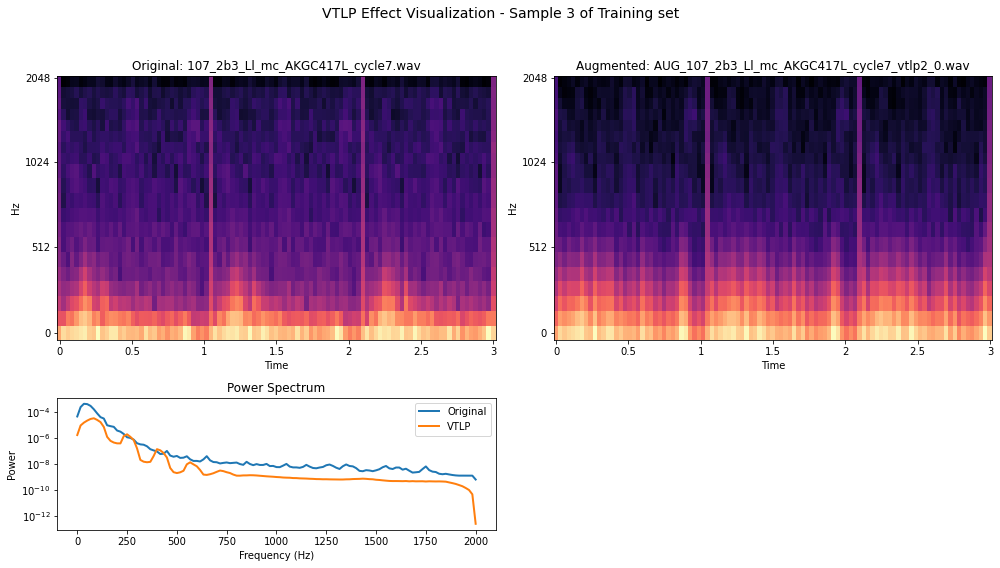

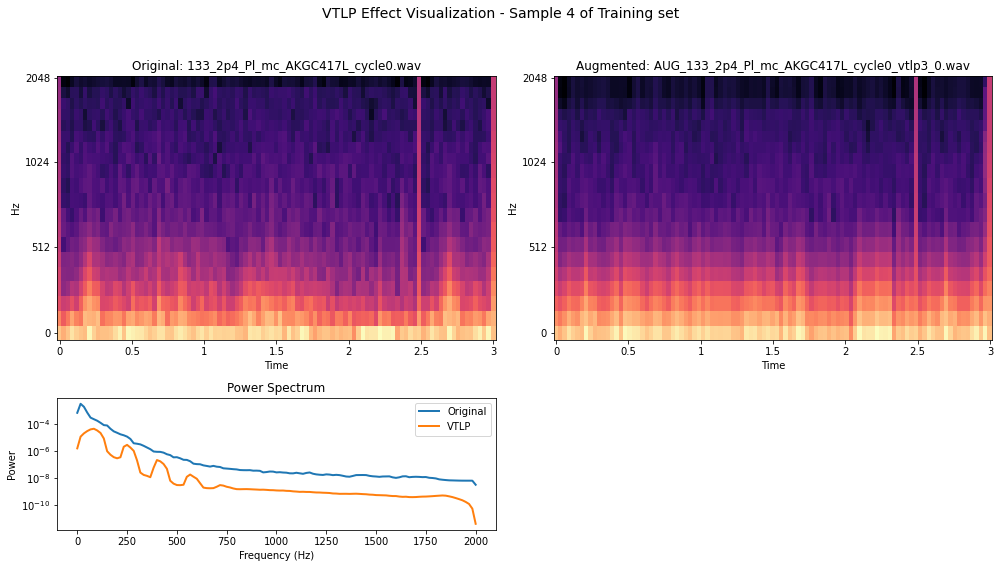

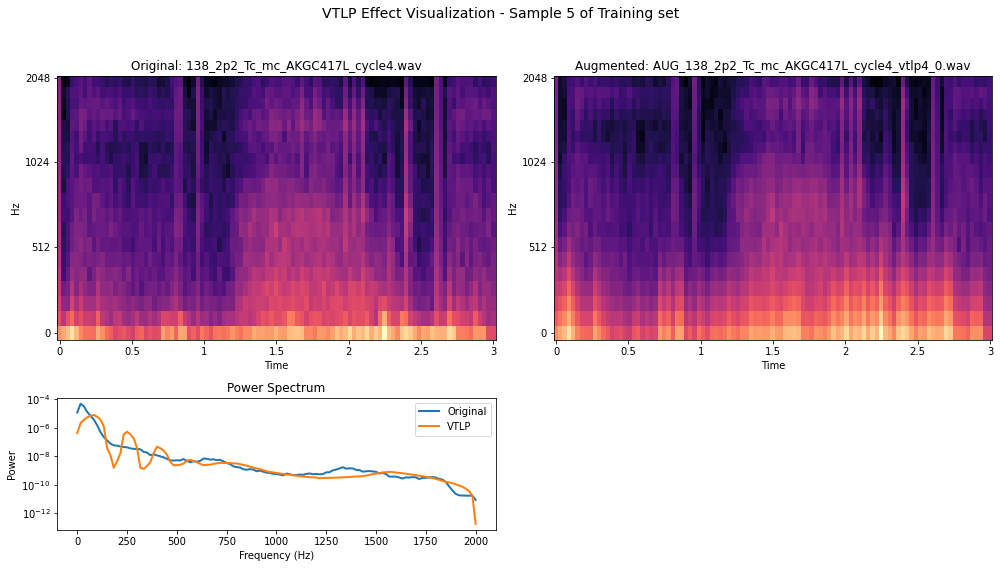

In [10]:
from utils.visuals import plot_vtlp_effects

plot_vtlp_effects(
    augmented_df=augmented_labels_df,
    raw_folder=RAW_CYCLE_FOLDER,
    aug_folder=AUG_CYCLE_FOLDER,
    k=5,
    sr=SAMPLING_RATE,
    n_fft=FRAME_SIZE,
    hop_length=HOP_SIZE,
    n_mels=N_MELS
)

In [11]:
# After the augmentation we check if each label is indeed equally represented
final_train_df = pd.concat([train_df, augmented_labels_df], ignore_index=True) # Combine raw and augmneted cycles for training set
print("\nClass distribution in training set after augmentation:")
for cls, count in final_train_df["class"].value_counts().items():
    print(f"{cls}: {count} instances")

final_df = pd.concat([final_train_df, test_df], ignore_index=True)


Class distribution in training set after augmentation:
Crackle: 2913 instances
Normal: 2913 instances
Wheeze: 2913 instances


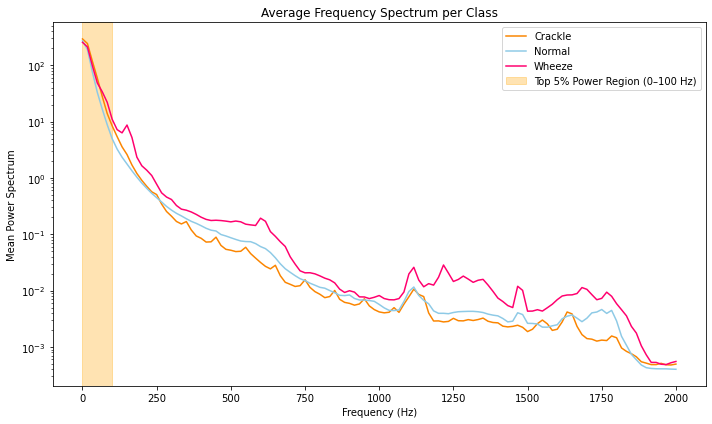

In [12]:
from utils.visuals import plot_average_spectrum_per_class

plot_average_spectrum_per_class(
    train_df=train_df,
    raw_cycle_folder=RAW_CYCLE_FOLDER,
    sampling_rate=SAMPLING_RATE,
    frame_size=FRAME_SIZE,
    hop_size=HOP_SIZE
)

In [13]:
# Step 5: Preprocess both sets: filter and normalize the amplitudes
for fname in tqdm(final_df["file"], desc="Preprocessing all cycles"):
    in_folder = RAW_CYCLE_FOLDER if not fname.startswith("AUG") else AUG_CYCLE_FOLDER
    y, sr = preprocess_audio(os.path.join(in_folder, fname), sr=SAMPLING_RATE, cutoff=100.0)
    sf.write(os.path.join(CLEANED_CYCLE_FOLDER, fname), y, sr)

Preprocessing all cycles: 100%|██████████| 10018/10018 [00:43<00:00, 231.62it/s]


We visualize the first 5 .wav files after the preprocessing pipeline. The signal waveform is split into the different respiratory cycles and every respiratory cycle is seen as an independent instance for the classification model.

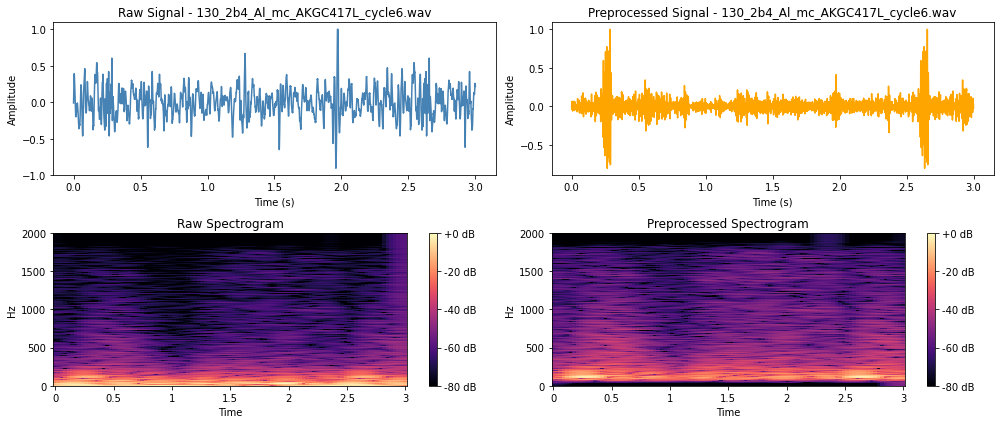

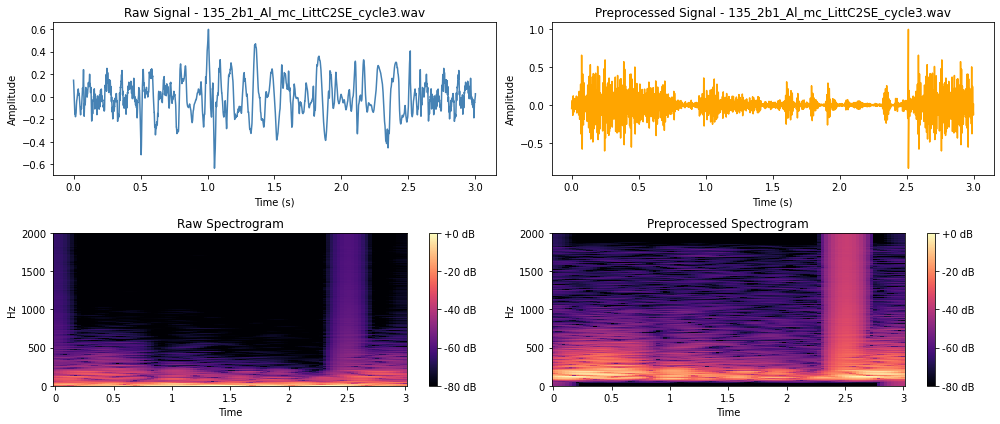

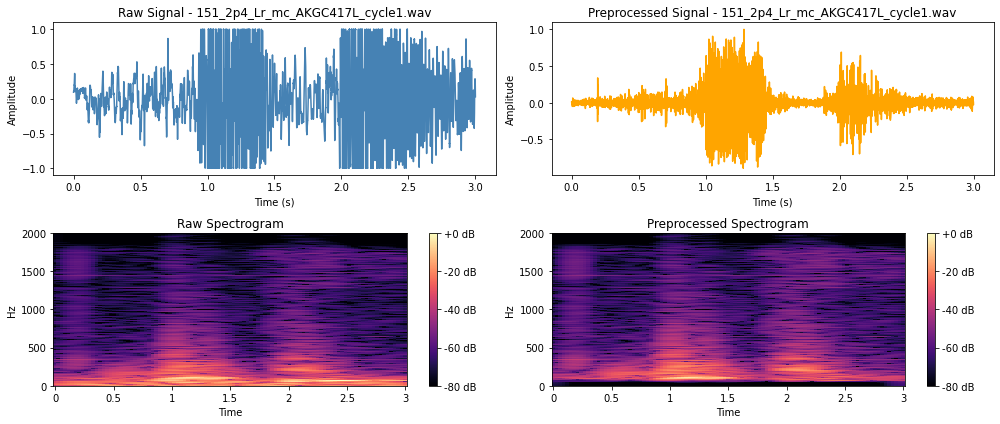

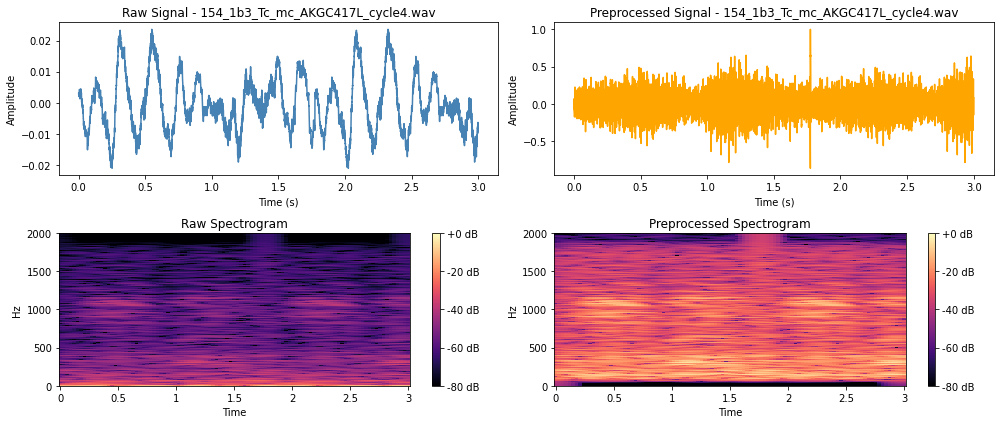

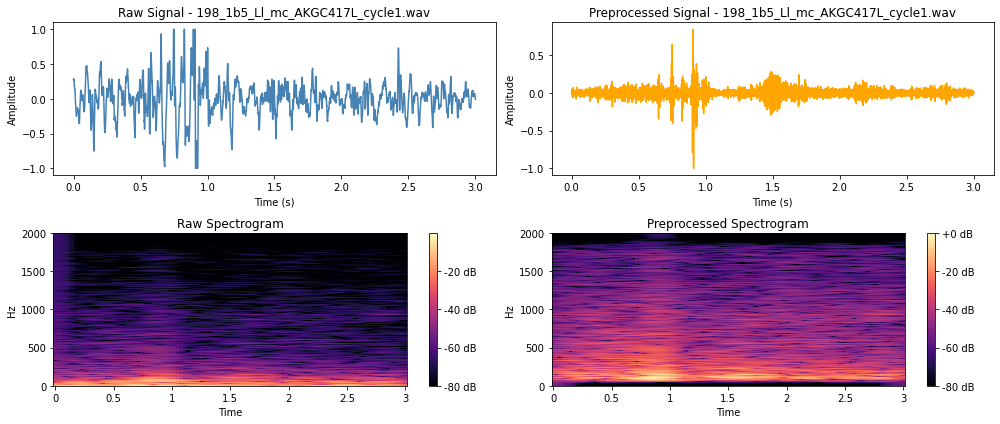

In [14]:
from utils.visuals import plot_signals_after_preprocessing

plot_signals_after_preprocessing(
    train_df=final_train_df,
    corrected_folder=CLEANED_CYCLE_FOLDER,
    raw_folder=RAW_CYCLE_FOLDER,
    sampling_rate=SAMPLING_RATE,
    hop_size=HOP_SIZE,
    k=5
)

The plots show that **the preprocessed signals appear smoother and more regular in amplitude**, indicating suppression of noise and artifacts. The corresponding **spectrograms reveal better-defined frequency structures and reduced background spectral clutter**. This suggests the preprocessing successfully enhanced the clarity and consistency of the breathing cycles while preserving important acoustic information.

In [15]:
final_train_df

,file,crackle,wheeze,class
0,130_2b4_Al_mc_AKGC417L_cycle6.wav,1,0,Crackle
1,135_2b1_Al_mc_LittC2SE_cycle3.wav,0,0,Normal
2,151_2p4_Lr_mc_AKGC417L_cycle1.wav,0,1,Wheeze
3,154_1b3_Tc_mc_AKGC417L_cycle4.wav,0,0,Normal
4,198_1b5_Ll_mc_AKGC417L_cycle1.wav,0,1,Wheeze
...,...,...,...,...
8734,AUG_198_1b5_Ll_mc_AKGC417L_cycle5_vtlp549_3.wav,0,1,Wheeze
8735,AUG_106_2b1_Pr_mc_LittC2SE_cycle4_vtlp550_0.wav,0,1,Wheeze
8736,AUG_106_2b1_Pr_mc_LittC2SE_cycle4_vtlp550_1.wav,0,1,Wheeze
8737,AUG_106_2b1_Pr_mc_LittC2SE_cycle4_vtlp550_2.wav,0,1,Wheeze


In [16]:
test_df

,file,crackle,wheeze,class
0,145_2b2_Ar_mc_AKGC417L_cycle3.wav,1,0,Crackle
1,192_2b1_Al_mc_LittC2SE_cycle2.wav,0,1,Wheeze
2,195_1b1_Ar_sc_Litt3200_cycle7.wav,0,0,Normal
3,205_1b3_Lr_mc_AKGC417L_cycle2.wav,1,0,Crackle
4,144_1b1_Al_sc_Meditron_cycle8.wav,0,0,Normal
...,...,...,...,...
1274,193_1b2_Ar_mc_AKGC417L_cycle6.wav,0,1,Wheeze
1275,163_8b3_Lr_mc_AKGC417L_cycle1.wav,0,0,Normal
1276,139_1b1_Ar_sc_Litt3200_cycle6.wav,0,0,Normal
1277,208_1b1_Ll_sc_Meditron_cycle11.wav,0,0,Normal


In [17]:
dfs = [
    (augmented_labels_df, "augmented_training_set.csv"),
    (train_df, "raw_training_set.csv"),
    (final_train_df, "training_set.csv"),
    (test_df, "test_set.csv"),
]

# Save augmented and final training set
for df, name in dfs[:3]:
    df.to_csv(os.path.join(TRAINING_SET_FOLDER, name), index=False)

# Save test set
df, name = dfs[3]
df.to_csv(os.path.join(TEST_SET_FOLDER, name), index=False)